# Feature analysis — `trade_rate_normalised`

This notebook is two things at once: a **method** for analysing a trading feature, and a **worked
example** of that method on one feature. The text explains what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three crypto
exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and **byb is the
target**: the one we predict. ("Mid-price" = the midpoint between the best buy and best sell quote.) The
next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature: **what it is and
why** (§1), **its exact definition** (§2), and **its builder** — the `trade_rate_normalised` function in
§3. The data loading, the checks, and the plots adapt on their own.

**The feature, in one line.** A venue's **trade rate** is how many of *that venue's* trades print per
second. We measure it the way the model measures byb's move-rate `λ_ev` — a span-`N` exp-weighted **count**
of the venue's trade-events ÷ a span-`N` exp-weighted **seconds-per-trade** — but counting **trades**, not
byb mid-moves:

`trade_rate(ex; N) = W_trades(ex; N) / E_dt(N)`   (the venue's trades per second)

then optionally divided by a regime **yardstick** to make it comparable across calm and busy markets:

`trade_rate_normalised(ex; N, y) = trade_rate(ex; N) / y`,   y ∈ { 1 (baseline), σ_ev, λ_ev }.

A high value means that venue is **trading more intensely than usual** — an activity surge. It is a
**rate-head (intensity)** feature: the hypothesis is that elevated trade intensity predicts a **burst** of
upcoming byb mid-moves. We build it for **byb, okx and bin** (the byb leg is the target's own trade
intensity; the okx/bin legs are cross-venue trade-intensity lead/lag), and we check the price head too.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second, production-style implementation reproduces the feature on real
  data, **for every per-venue leg × normalisation**, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo of "the market
  is busy right now."

Everything after that decides *which part of the model* the feature feeds, and *at what time-scale* — and
the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not
ship-done.

> **Control-circularity caveat — read this first, it is the crux of this feature.** The model's **rate
> controls** (`rate_momentum`, `rate_level`) are built from **`λ_ev` = byb's mid-MOVE rate**. A venue's
> **trade** rate is a *different* quantity: **trades need not move the mid** (a trade that doesn't cross a
> level leaves the BBO unchanged), and **the mid moves without trades** (a quote revision moves the mid
> with no print). So even byb's *own* trade rate is **not** a re-parameterisation of the move-rate control
> — it can carry marginal value the control does **not**. The honest test is therefore the **marginal over
> the rate/vol controls**, per venue (§6/§9), reported straight.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the model
does. We forecast how byb's mid-price moves over the next ~100 ms, and we split that into two simpler
questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move (its
direction *and* its size, together)? The head predicts the whole distribution of that move, in units of
byb's recent **volatility** — the **volatility yardstick** `σ_ev` (the exp-weighted RMS of byb's *actual*
mid-moves) — so the head's target is `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few. This
head predicts the *count* of moves over the next 100 ms as a distribution, measured against the recent
pace — the **rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`. **This is `trade_rate_normalised`'s
home.**

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you
want it gone, dividing by the yardstick is **one option** for removing it (only *when applicable*). Both
are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but **updated between trades** — they react to
every byb mid-move, so they read live at every instant. They use one fixed span, `YARDSTICK_N` (this
feature borrows that span as one of its optional normalisers). (`σ_ev` is the exp-weighted RMS of byb's
*actual* mid-moves — read as an `E/W` ratio so the many non-move trades cancel out; `λ_ev` is a ratio of
two EMAs — the exp-weighted byb move-count `W` ÷ the exp-weighted seconds-per-trade = byb's moves per
second.) Critically, **`λ_ev` counts byb mid-moves, while this feature counts trades** — the two are
genuinely different clocks (see the caveat above). Like every average here, they live on the trade-tick
clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen times *how big*
each one is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier thing
— and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*, one per
possible move-count: "if `k` moves happen, here's the spread of the total price change" (call it `D_k`).
The rate head gives the probability of each count, `P(K = k)`. The 100 ms move is the two **mixed** — for
every count `k`, take the price head's `k`-move distribution, weight it by the rate head's probability of
exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's `D_k` sets
the shape. `trade_rate_normalised` is squarely a **how-many / intensity** feature — it speaks to the rate
head's "how many."

**Backed by research.** This "how many × how big" split is the classic **subordination** model of asset
prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns over a fixed
clock-time window look messy, but become well-behaved once you condition on the *number* of events. So
modelling the event count and the per-event move separately, then mixing them, is a principled
decomposition — not just a convenient one.

Two diagnostics recur below: does a feature's *signed* value predict the move (price head), and does its
*magnitude/level* predict how many moves come (rate head)? The model is fed the **signed** feature for
*both* heads; the rate head learns the magnitude itself. For `trade_rate_normalised` we expect the rate
head to be its home, if anywhere — and they are **marginal screens** (does the feature carry signal worth
feeding), **not** measures of distributional fit, which is judged at the model level downstream.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build the feature
  the same way for **every** venue and keep them all. (Here that is literal: byb, okx and bin each get
  their own trade-rate leg; the okx/bin legs are exactly the "does another venue's trade intensity lead
  byb?" test.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another venue leads.
  Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a poolable
  feature (this one *is* poolable — a per-venue rate, not a gap *between* exchanges), first check
  per-exchange vs single vs pooled across time-scales (§9).
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — but **note the
  controls here are byb's mid-MOVE rate/vol, not trade rate**, so the feature is *not* a re-parameterised
  control. Its marginal can be genuinely positive.
- **Don't normalize reflexively — but DO test it here.** `trade_rate` has units (trades/sec), so it is
  **not** automatically comparable across calm/busy markets; that is the whole reason this feature carries
  the **normalisation axis**. We build three variants — un-normalised, `/ σ_ev`, `/ λ_ev` — and let the
  data say which (if any) helps, using the **model's** yardsticks (never a home-grown scale).
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it
  on real data, for **every** per-venue leg.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works (§8).

**Do**
- **Do start with a falsifiable hypothesis** — a venue's elevated trade intensity precedes more byb
  mid-moves. Disproof: no link to the forward move-count at any time-scale / any normalisation for any
  venue; or the link fully explained by the byb move-rate control.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — every venue's
  trade-count leg, the seconds-per-trade leg, `σ_ev`, `λ_ev` — is an exponential moving average **decayed
  once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues;
  simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per
  timestamp that carries a relevant event** (a trade of its own exchange — same-timestamp events as one
  update, never stale between trades), **never** a wall-clock average and **never** a hard/boxcar window.
  That keeps the whole state **O(1)** (one scalar per average, no ring buffers) and bit-identical online
  vs offline. Establish and validate the convention against a plain one-event-at-a-time loop on a real
  block — exactly as `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks
  here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For this feature, that relevant event
  is a trade of *its own* venue: it injects that timestamp's one trade-event mark. A value that ignores
  its own trades since the last clock read is **stale** — wrong, and a silent source of lag. The choice of
  EMA *and when it updates* is what makes the read well-behaved — pick both deliberately (see the
  "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for `W_trades(ex)`, a trade of *this* venue; for `σ_ev`, a byb mid-move. A timestamp with
  only **irrelevant** trades injects nothing for that EMA, yet it still **ticks** (decays) once *iff* a
  trade lands, on the one **shared** trade clock (one tick per trade-timestamp across **all** venues,
  simultaneous prints counting once). Inject and decay are independent and neither ever fires more than
  once per timestamp, whatever the feature. Records sharing a timestamp are **one** sample, not a sequence:
  for `W_trades(ex)` the value is the **trade-event indicator** `1`, never the print count. So a backed-up
  burst of N trade prints at one instant is still **one** weight-1 sample — value `1` — **never** N
  samples. Injecting N silently overweights exactly the instants where a feed stalled and dumped a burst
  (78% of byb prints share a timestamp here, so this matters), corrupting `W_trades`.
- **Do read a sparse flow as `E / W` on the shared clock.** A quantity present on only *some* events
  (each venue's trade-events; byb's own mid-moves — `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W` (or its `dt` denominator),
  both decayed every trade-timestamp yet each pushed a sample only at the timestamps carrying its own
  events — read as a ratio, which cancels the in-between decay and the warm-up bias. Per the
  merged-clock ↔ own-clock equivalence, a one-clock EMA at span `N` approximates that venue's **own**-clock
  count at a rescaled span — genuine per-venue rates from the one shared clock. (That equivalence — tight
  at large `N`, fraying at small `N` where the cross-venue lead/lag lives — is what
  `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** The magnitude/level→intensity
  (rate-head) check is the one that matters; the price-head check is a diagnostic we expect to be weak
  (intensity isn't direction). In the model, feed the **signed** (here log) feature to *both* heads.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single
  split is only a faster screen.
- **Do treat a feature as a family across time-scales** and sweep the WHOLE span grid, per venue — and
  across all three normalisations — and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm
  and wild markets: its distribution must be **stable against the regime diagnostics we track** (not a
  proof of independence). Gate A's **control-free** checks (§6): **scale** (std stable across vol buckets,
  max/min < ~3); and — for **both the signed feature and its magnitude `|feature|`** — that it does **not
  track** the regime (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically**
  (per-decile-mean **dispersion** small). A raw **level** (a raw `trades/sec` rate) usually *is* the
  regime and fails them — but *measure, don't assume*: a **ratio / bounded / normalised** form may pass.
  This is exactly the normalisation axis: a raw `baseline` rate is expected to fail the scale gate, while
  `÷ λ_ev` (trades per byb-mid-move, a pure rate ratio) may pass. Never call a feature regime-invariant
  *or* not until **every** Gate A number says so.
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — they
  serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the feature
  under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal. (But note: trade rate ≠ byb move rate, so even byb's own trade-rate leg is **not**
  circular with the move-rate control — its honest test stays the marginal.)

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**. If there's no
story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | a venue's **trade rate** (trades/sec) at a span `N`, optionally ÷ a regime yardstick — one per venue (byb, okx, bin), three normalisations |
| **feeds** | the **rate head** (intensity: how many byb moves next) is the natural home; the price head is a diagnostic; both are fed the *signed* (log) feature |
| **predicts** | byb's 100 ms move-count (and, weakly if at all, direction) |

**The idea.** Count how often a venue *trades*. Express it as a rate — trades per second — using the exact
`W / dt` form the rate yardstick `λ_ev` uses, but with `W` counting **trade-events** (one per the venue's
trade-timestamp) instead of byb mid-moves. That is a single span-`N` EMA, no fast/slow pair. Then
optionally divide by a yardstick to strip the regime: nothing (`baseline`), `σ_ev` (vol), or `λ_ev`
(byb's move rate). **Do this for byb, okx and bin** — the byb leg is the target's own trade intensity, the
okx/bin legs are other venues' trade intensity.

**Why it should work.** Trading activity clusters. When information arrives or inventory is worked, a
venue's print rate jumps and stays elevated for tens to hundreds of milliseconds, so a high trade rate
forecasts a **burst** of upcoming byb mid-moves. For the **cross-venue** legs there is an extra mechanism:
if okx (or bin) starts trading heavily first, that intensity can **lead** byb by a beat — the classic
no-fixed-leader lead/lag. This is an *intensity* statement: *how many* moves, not *which way* — the **rate
head**.

**Why trade rate is NOT the rate control (the crux).** The model's rate controls are built from `λ_ev` =
byb's **mid-move** rate. A venue's **trade** rate is a different quantity: a trade that doesn't lift a
level leaves the mid unchanged (trade-no-move), and a quote revision moves the mid with no trade
(move-no-trade). So even byb's *own* trade rate is **not** a re-parameterisation of the move-rate control
— it can carry marginal value the control does not. This is exactly what §6/§9 measure, per venue, and the
normalisation axis (§3) asks whether dividing by `σ_ev` or `λ_ev` sharpens or destroys that value.

**The normalisation axis, three ways.** `trade_rate` has units, so on its own it partly re-reports the
overall pace. (a) **baseline** keeps the raw rate — comparable only if the trade-rate regime is itself the
signal. (b) **÷ σ_ev** puts it in inverse-vol units. (c) **÷ λ_ev** makes it **trades per byb-mid-move** —
arguably the most interpretable: "how many prints per move," a microstructure ratio that is high when
trading is churny relative to price discovery. We build all three and report which helps — choosing
**regime-invariance-first** (a non-invariant level is disqualified however high its raw IC).

**What would disprove it.** No link to the forward byb move-count at any span / any venue / any
normalisation; or the link vanishing once we control for `rate_momentum`/`rate_level` (then it *was* just
the move-rate regime after all, despite the mechanism).

> **No fixed leader.** Built the same way for every venue, all kept. The okx/bin legs are precisely the
> "another venue's trade intensity might lead" test; the trade clock pools all three venues' trades. (§9
> sweeps when per-exchange beats a single venue for this poolable feature.)

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). For each venue's `trade_rate` the moving parts are:

- **The trade-count numerator `W_trades(ex)`** — a **sparse flow** (venue `ex` trades on only *some*
  shared-clock ticks). It is an EMA that **decays every shared trade-tick** and **injects `1` on each `ex`
  trade-timestamp**, read **live** at the anchor. This is the same `E/W`-style flow the yardsticks use, but
  the injected mark is a **trade-event indicator**, not a mid-move. Per the merged-clock↔own-clock
  equivalence, dividing through by the common decay makes this a *per-venue* count even though all venues
  share one clock.
- **The seconds-per-trade denominator `E_dt`** — a **per-trade** EMA of the gap between consecutive
  trade-timestamps, held flat between trades. This is a property of the **shared clock**, so it is the
  same for every venue; the per-venue content lives entirely in `W_trades(ex)`.

So `trade_rate(ex; N) = W_trades(ex; N) / E_dt(N)` = venue `ex`'s trades per second at span `N`.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (a venue's trade-events; byb's mid-moves): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. The `W` denominator counts only the events that carry
  the quantity, so the read is a *per-event mean*. `W_trades(ex)` is exactly such a flow (the injected mark
  is `1`).
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`**; this feature is a flow/rate, not a level, so it does **not** use it.

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the quantity
the EMA is measuring:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (`W_trades(ex)`: inject `1` on a trade of *this* venue; `σ_ev`: push `r²` only on a byb move) |
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** | a level — not used here |

The trap the template warns about (push a `0` on a non-event and "per X" silently becomes "per tick")
applies here too: `W_trades(ex)` must inject **only** on a real `ex` trade-timestamp, and **once** per
timestamp (simultaneous prints are one event — inject `1`, never the print count). The §4 parity check
re-derives all of this from raw events, per venue, and confirms it bit-exact.

**A subtlety vs the template's gap.** This is a **single** EMA, not a fast/slow ratio, so it does **not**
self-cancel its units — which is exactly why the normalisation axis exists. The numerator is a *count
indicator* (mark `1` per trade-event), not a *gap* or a *mid-move*; everything else is the same
shared-clock `W / dt` machinery.

## 2. The exact definition

A definition has to get three things right.

**Causal** — only data up to the moment it's computed; no peeking. (A stray forward-fill is the usual
accidental break.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades* (one
tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than clock-seconds. A
venue's trades between *other* venues' trades update what its `W` reads but the decay clock advances once
per shared trade-timestamp.

**Comparable across calm and wild markets** — here this is the **open question**, not a given.
`trade_rate` has units (trades/sec), so unlike a ratio it is **not** automatically comparable. That is why
the feature carries a **normalisation axis**: we build the raw rate and two yardstick-divided variants and
let §6 say which is comparable-and-predictive (the **regime-invariance scale** gate decides, raw-first).

Put it together, **for each venue `ex`** and each normalisation `y ∈ {1, σ_ev, λ_ev}`:

**2a — The shape** (the whole idea, in one line):

`trade_rate_normalised(ex; N, y) = trade_rate(ex; N) / y`,   `trade_rate(ex; N) = W_trades(ex; N) / E_dt(N)`.

A fresh burst of `ex` prints shows up as `W_trades(ex)` rising, so `trade_rate` rises; the optional ÷ y
strips the vol or move-rate regime.

**2b — The EMAs we use, and how they update:**

- **`W_trades(ex; N)`** (per-venue trade-count numerator) — a **sparse flow**: decay once per
  trade-timestamp on the shared clock (`α=2/(N+1)`), inject `1` on each real `ex` **trade-timestamp**,
  read **live** at the anchor.
- **`E_dt(N)`** (seconds-per-trade denominator) — a **per-trade** EMA of `Δ(trade timestamp)/1e9`, held
  flat between trades; a property of the shared clock (same for all venues).
- **`σ_ev`, `λ_ev`** (yardsticks, span `YARDSTICK_N`) — `σ_ev = √(E/W)` over **byb mid-moves**;
  `λ_ev = W_byb_moves / E_dt` at `YARDSTICK_N` (byb's mid-moves per second). Used both as the optional
  normalisers **and** to build the §5 controls and the rate-head target. **Note `λ_ev` counts byb
  mid-moves; the feature counts trades — different streams.**

§3 builds exactly this; §4 re-derives it from raw events, per venue, and confirms it bit-exact. The cell
below loads the data, builds the shared trade clock, computes each venue's trade-event stream, and computes
both yardsticks (from byb mid-moves) as `E/W` / `W÷dt` flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we PREDICT; byb mid also feeds σ_ev/λ_ev & the targets
EXCHANGES   = ["byb", "okx", "bin"]              # EVERY venue gets its own trade-rate leg (byb = own; okx/bin = cross-venue)
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}  # byb/okx mid = merged (trade-fused); bin = front_levels (merged blocked for bin perp)
SPANS       = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000]  # the WHOLE lookback family for the single trade-rate EMA span (1 = no smoothing)
NORMS       = ["baseline", "sigma", "lambda"]    # the normalisation axis: raw rate, ÷ σ_ev, ÷ λ_ev
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): trade-tick EMA α=2/(N+1)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load byb's mid-price stream (drives σ_ev/λ_ev and the prediction targets)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
byb_rx0, byb_mid0 = load_mid("byb")

# per-venue TRADE stream + the shared trade clock. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_rx = {}                                     # ex -> unique trade-TIMESTAMPS (one per trade-event for that venue)
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy()
    trade_rx[ex] = np.unique(rx)                  # collapse this venue's simultaneous prints to ONE trade-EVENT (inject 1, not the print count)
    trade_ts.append(rx)
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # shared trade clock: one tick per trade-TIMESTAMP (any venue)
n_ticks = len(merged_ts)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9 # seconds between consecutive trades (shared clock; same dt for every venue)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")
print("per-venue trade-EVENTS (simultaneous prints collapsed): " + "  ".join(f"{ex}={trade_rx[ex].size:,}" for ex in EXCHANGES))

# --- byb mid-MOVE stream for the yardsticks: react to every byb mid-move, decay once per shared trade ---
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP mids to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running byb move count (rate-head target)

def _ewma(x, span):                                                # per-trade EMA (seconds/trade leg; shared clock)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(val_rx, val, anchors, span):   # live EWMA of `val` over a SPARSE event stream (val_rx), decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, val_rx, "left")                              # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(val_rx, anchors, "right")] - cs[np.searchsorted(val_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def dt_at(anchors, span):                   # seconds/trade EMA on the shared clock (per-trade, held flat between trades)
    return _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]
def trade_rate(ex, anchors, span):          # venue ex's TRADE rate at a span: live trade-EVENT count W ÷ shared seconds dt = trades/sec
    w  = _flow_at(trade_rx[ex], np.ones(trade_rx[ex].size), anchors, span)         # W_trades(ex): exp-weighted ex trade-event count (live at anchor)
    return w / np.maximum(dt_at(anchors, span), 1e-12)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev from BYB MID-MOVES — defined AT the anchor
    e_sq = _flow_at(mv_rx, mv_r2, anchors, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(mv_rx, np.ones(mv_r2.size), anchors, span)    # W: exp-weighted byb-MOVE count
    e_dt = dt_at(anchors, span)                                   # seconds/trade
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-MOVES per second  (NOT trades/sec)
    return sig, lam
print(f"yardsticks (from byb mid-moves): decay span {YARDSTICK_N} trades; λ_ev = byb MID-MOVES/sec (≠ trade rate)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
per-venue trade-EVENTS (simultaneous prints collapsed): byb=351,008  okx=585,948  bin=745,299
yardsticks (from byb mid-moves): decay span 10000 trades; λ_ev = byb MID-MOVES/sec (≠ trade rate)


## 3. Build it (twice), across all three normalisations

Build the feature two ways: this fast array version for analysis, and — in production — a streaming
version that does constant work per trade (no growing buffers). They have to agree, which §4 checks.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms
outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's
walk-forward gate uses an embargo), read byb's actual move and move-count over the next 100 ms (the things
we're predicting), and compute the feature **per venue, per normalisation** at each grid point.

**The normaliser is applied at the read.** `trade_rate(ex; N)` is built once per (venue, span); the three
variants are just that rate ÷ {1, σ_ev, λ_ev} at the anchor — so they share the heavy machinery and differ
only by a scalar divide.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (a diagnostic for this rate feature): byb's 100 ms return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # price-head target (σ-units)

# rate-head target = byb moves in the next 100 ms ÷ λ_ev (the rate yardstick) — the head this feature serves
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)          # count ÷ λ_ev ∝ "more/fewer moves than usual"

_YARD = {"baseline": np.ones_like(sigma_at_anchor), "sigma": sigma_at_anchor, "lambda": lam_at_anchor}
def trade_rate_normalised(ex, span, norm):  # THE FEATURE, per venue / span / normalisation
    r = trade_rate(ex, anchor_ts, span)                           # trades/sec at this span
    return r / np.maximum(_YARD[norm], 1e-300)                    # ÷ {1, σ_ev, λ_ev}
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    demo = trade_rate(ex, anchor_ts, 100)
    print(f"  trade_rate({ex},100): median {np.nanmedian(demo):.1f} trades/s  p10 {np.nanpercentile(demo,10):.1f}  p90 {np.nanpercentile(demo,90):.1f}")
# sanity: trades/sec vs byb mid-moves/sec (λ_ev) — different magnitudes => trade rate ≠ move rate
print(f"  byb λ_ev (mid-moves/s) median {np.nanmedian(lam_at_anchor):.1f}  vs byb trade_rate median {np.nanmedian(trade_rate('byb', anchor_ts, 100)):.1f}  -> distinct clocks")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


  trade_rate(byb,100): median 2.3 trades/s  p10 0.8  p90 8.5


  trade_rate(okx,100): median 4.2 trades/s  p10 2.0  p90 12.1


  trade_rate(bin,100): median 5.1 trades/s  p10 2.6  p90 14.6


  byb λ_ev (mid-moves/s) median 1.2  vs byb trade_rate median 2.3  -> distinct clocks


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two agree on real
data — a **parity check** — **bit-exact**, **for every per-venue leg × normalisation**. The streaming
build is the **production** reference: an O(1) state machine you push **raw events** into and read
`value(ex, span, norm)` from. State is a few scalar EMAs per venue — no buffers, no history, independent of
how long it runs.

**The design.** This is the **production** code path: the streaming build wires up only `boba.ema`'s
tested classes (no `lfilter`, no `_flow_at` — those are §3's offline array helpers), each fed one raw event
at a time on the shared trade clock. The library classes are the actual online EMAs the live system uses;
parity against §3's independent vectorized `lfilter` path is the cross-check (two genuinely different code
paths — online `boba.ema` vs offline `lfilter` — computing the same feature):

- **`W_trades(ex; N)`, per venue per span** — a sparse trade-event **flow**: a **`KernelMeanEMA`** with
  mark `1` (`add(1.0)` on each `ex` **trade-timestamp**, once even for many simultaneous prints; `tick()`
  once per trade-timestamp on the shared clock). We read its running mass `E` — the live exp-weighted
  trade-event count at the anchor.
- **`E_dt(N)`, per span** — one **`KernelMeanEMA`** per span (shared across venues): once per trade it
  `tick()`s (decay) then `add(gap)`s the seconds since the previous trade, and we read its **mass `E`**
  (the un-normalised seconds-per-trade EMA — `tick`-then-`add` reproduces the plain `(1−α)·s + α·gap`
  recursion exactly, and the `α` cancels against `W_trades`'s `E` in the ratio). Held flat between trades.
- **σ_ev, λ_ev** — a single **`KernelMeanEMA`** over byb mid-moves (`add(return²)` on a byb move, `tick()`
  each trade): `σ_ev = √(value())` (its `E/W`), and `λ_ev = W_byb_moves / E_dt(YARDSTICK_N)` using that
  same EMA's move-count mass `W`; used as the normalisers and validated alongside.
- **trade_rate = W_trades / E_dt**, and the three variants divide by {1, σ_ev, λ_ev}.

**Driver discipline (matches the trade clock):** apply every record at a timestamp, then `refresh()` once
— detect **each venue's** trade-presence and inject its `W` (once), detect byb's mid-move and inject σ_ev,
advance the clock (decay every `W` and the byb masses, step every `dt`) **at most once**, and only if a
trade landed. A book-only instant moves byb's mid without advancing the clock. We feed the **whole raw
stream** — every venue's book updates and trades — into **one** builder and read **every venue's** feature
at each grid anchor, at the **shipped rate-head spans** (the §6 picks) plus span 100 for breadth, across
all three normalisations — so every leg/span/normalisation we actually ship is validated bit-exact.

In [3]:
import boba.io as io                  # used ONLY to read raw events (load_block / _trade_lifts_ask) — NOT for any EMA/feature math
import math
from boba.ema import KernelMeanEMA            # the ONLY online EMA used here: sparse-flow E/W mass (W_trades, σ_ev) AND the seconds-per-trade mass E_dt, src/boba/ema.py

class LiveTradeRate:
    # Pure feature state machine for per-venue TRADE rates (+ the byb yardsticks for normalisation). O(1), all scalar.
    # EVERY online EMA is boba.ema's KernelMeanEMA — the PRODUCTION code, not a throwaway re-implementation (EventEMA is BANNED):
    #   W_trades(venue, span) is a KernelMeanEMA fed mark 1 (add(1) on each venue trade-timestamp, tick() each trade); we read
    #     its running mass E = the live exp-weighted trade-EVENT count.  E_dt(span) is ALSO a KernelMeanEMA: each trade-timestamp it
    #     tick()s (decay) then add(gap) (inject the seconds-since-last-trade), and we read its mass E — the un-normalised
    #     seconds-per-trade EMA (tick-then-add on the shared clock reproduces the plain (1-α)·s+α·gap recursion bit-for-bit,
    #     started from 0; the α cancels against W_trades.E in the ratio).  trade_rate = W_trades.E / E_dt.E.
    #   σ_ev/λ_ev: ONE KernelMeanEMA over byb mid-moves (add(return², weight 1) on a move, tick() each trade) — σ_ev = sqrt(E/W),
    #     and λ_ev = W_byb_moves / E_dt(YARDSTICK_N) reuses that EMA's move-count mass W.
    # The driver applies all records at a timestamp, then calls refresh() once: register EACH venue's trade-presence
    # (-> add 1 to its W EMA) and byb's mid-move (-> add return² to the vol EMA), then tick the clock AT MOST ONCE (only if a trade landed).
    def __init__(self, target, venues, spans, vol_span, fuse_trades):
        self.target = target
        self.venues = list(venues)                                         # full listings we track a trade-rate for (byb,okx,bin)
        self.spans = sorted(set(spans))                                    # all distinct EMA spans we need
        self.vol_span = vol_span
        self.fuse_trades = set(fuse_trades)
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.W = {v: {N: KernelMeanEMA(N) for N in self.spans} for v in self.venues}  # live trade-EVENT flow per venue per span (read its mass E)
        self.dt = {N: KernelMeanEMA(N) for N in self.spans}                # seconds-per-trade EMA per span (shared clock); read its mass .E (un-normalised)
        self.dt_y = KernelMeanEMA(vol_span)                                # seconds-per-trade at the yardstick span (for λ_ev); read .E
        self.vol = KernelMeanEMA(vol_span)                                 # σ_ev: E/W of squared byb moves; its W is the λ_ev move-count mass
        self.prev = None                                                   # byb's last log-mid, to detect a real move
        self.prev_ts = None                                                # last trade-timestamp (for the dt gap)
        self.traded_venues = set()                                         # which venues traded THIS timestamp
        self.was_trade_present = False

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self, ts):                                                # ONE per TIMESTAMP
        traded = self.was_trade_present; self.was_trade_present = False
        tv = self.traded_venues; self.traded_venues = set()
        for v in tv:                                                      # inject each venue's trade-EVENT (ONCE per timestamp, before decay)
            for N in self.spans: self.W[v][N].add(1.0)                    # mark 1 -> KernelMeanEMA mass E is the trade-event count
        m = self._mid(self.target)                                        # byb mid-move -> inject σ_ev (and the λ_ev move-count = its W)
        if m is not None:
            lm = math.log(m)
            if self.prev is not None and lm != self.prev:
                self.vol.add((lm - self.prev) ** 2)                       # σ_ev: E/W of squared moves; W counts the moves (= λ_ev numerator)
            self.prev = lm
        if traded:                                                        # a trade landed -> advance the clock exactly once
            gap = 0.0 if self.prev_ts is None else (ts - self.prev_ts) / 1e9
            for N in self.spans:
                for v in self.venues: self.W[v][N].tick()                 # decay every venue's trade-count EMA one trade-tick
                self.dt[N].tick(); self.dt[N].add(gap)                    # seconds-per-trade EMA: decay one tick, then inject the gap (tick-then-add = (1-α)·s+α·gap)
            self.dt_y.tick(); self.dt_y.add(gap)                          # yardstick-span seconds-per-trade (same tick-then-add)
            self.vol.tick()                                               # decay σ_ev (E and W) one trade-tick
            self.prev_ts = ts

    def on_book(self, listing, t, bid, ask):
        if listing in self.fuse_trades:
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.traded_venues.add(listing)                                   # this venue traded this timestamp (one event, regardless of print count)
        self.was_trade_present = True

    def _rate(self, v, N):
        d = self.dt[N].E                                                  # un-normalised seconds-per-trade mass (0 before the first trade)
        if not (d > 1e-12): return float("nan")                           # not warmed up (no trade yet) -> nan
        return self.W[v][N].E / d                                         # live trade-event count mass ÷ seconds-per-trade

    def sigma(self):
        s2 = self.vol.value()                                             # E/W of squared moves (nan before first move)
        return math.sqrt(s2) if s2 == s2 else float("nan")
    def lam(self):
        d = self.dt_y.E                                                  # un-normalised seconds-per-trade mass at the yardstick span
        if not (d > 1e-12): return float("nan")
        return self.vol.W / d                                            # byb move-count mass (the vol EMA's W) ÷ seconds-per-trade

    def value(self, v, N, norm):                                          # the feature for venue v at span N, normalisation norm
        r = self._rate(v, N)
        if norm == "baseline": return r
        if norm == "sigma":
            s = self.sigma(); return r / s if (s == s and s > 0) else float("nan")
        l = self.lam();        return r / l if (l == l and l > 0) else float("nan")

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
# Validate the SHIPPED rate-head spans (the §6 picks, populated below) PLUS span 100 for breadth, for ALL THREE venues
# and ALL THREE normalisations, over ~N_GRID grid points.
VAL_SPANS, N_GRID = [10, 30, 100], 40_000
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept <= cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time)
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
df = (load_block(block, f"bin_{COIN}", MID_STREAM["bin"]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())  # book-only venue: bin's front_levels mid
brx = df["rx_time"].cast(pl.Int64).to_numpy(); bmid = (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
add(brx, 0, 2, brx, bmid, bmid)                    # bin: fed as bid=ask=mid (book-only); bin still trades -> its own trade-rate leg
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once, READ value() for EVERY venue/norm at every grid anchor ---
fuse = {f"{ex}_{COIN}" for ex in EXCHANGES if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
VENUES = [f"{ex}_{COIN}" for ex in EXCHANGES]
feat = LiveTradeRate(TARGET, VENUES, VAL_SPANS, YARDSTICK_N, fuse)
na = min(N_GRID, len(anchor_ts))
stream = {(ex, nm, N): np.full(na, np.nan) for ex in EXCHANGES for nm in NORMS for N in VAL_SPANS}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES:
            for nm in NORMS:
                for N in VAL_SPANS: stream[(ex, nm, N)][ai] = feat.value(f"{ex}_{COIN}", N, nm)
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    feat.refresh(rx)                               # apply the timestamp: inject each venue's W + byb σ_ev, advance the clock once if a trade landed
while ai < na:
    for ex in EXCHANGES:
        for nm in NORMS:
            for N in VAL_SPANS: stream[(ex, nm, N)][ai] = feat.value(f"{ex}_{COIN}", N, nm)
    ai += 1

# --- one raw-event stream -> 3 venues × 3 normalisations × shipped spans: check EACH against its §3 vectorized feature, bit-exact ---
# Bit-exactness here is a MAGNITUDE-RELATIVE tolerance: the σ_ev-normalised legs carry values ~1e5-1e6 (trade_rate ÷ a
# ~1e-5 σ_ev), so their *absolute* round-off is large while their *relative* error stays ~1e-12. We gate on
# |diff| / (1 + |ref|) < 1e-9 (and print the raw absolute |diff| too); an absolute floor alone would be a unit-dependent check.
print(f"one raw-event stream -> per-venue × per-normalisation × shipped-span trade-rate legs, vs the vectorized build (spans={VAL_SPANS}):")
worst_abs = 0.0; worst_rel = 0.0
for N in VAL_SPANS:
    for ex in EXCHANGES:
        for nm in NORMS:
            ref = trade_rate_normalised(ex, N, nm)[:na]
            both = np.isfinite(stream[(ex, nm, N)]) & np.isfinite(ref)
            a_diff = np.abs(stream[(ex, nm, N)][both] - ref[both])
            r_diff = a_diff / (1.0 + np.abs(ref[both]))               # magnitude-relative: bit-exact regardless of feature scale
            mx_a = float(np.nanmax(a_diff)); mx_r = float(np.nanmax(r_diff))
            worst_abs = max(worst_abs, mx_a); worst_rel = max(worst_rel, mx_r)
            print(f"  span {N:>3}  {ex:4} / {nm:8}:  rel |diff| {mx_r:.2e}  (abs {mx_a:.2e})  on {int(both.sum()):,} grid points")
            assert mx_r < 1e-9, f"live streaming build does not reproduce the {ex}/{nm} feature at span {N} (rel |diff|={mx_r:.2e})"
print(f"parity: the raw-event streaming build reproduces ALL legs × normalisations × shipped spans  OK  (worst rel |diff| {worst_rel:.2e}, worst abs {worst_abs:.2e})")

streaming 3,211,783 raw events (book + trades, all venues) over ~40,000 grid points...


one raw-event stream -> per-venue × per-normalisation × shipped-span trade-rate legs, vs the vectorized build (spans=[10, 30, 100]):


  span  10  byb  / baseline:  rel |diff| 9.91e-16  (abs 9.09e-13)  on 40,000 grid points


  span  10  byb  / sigma   :  rel |diff| 3.08e-14  (abs 1.94e-06)  on 40,000 grid points


  span  10  byb  / lambda  :  rel |diff| 5.70e-14  (abs 2.09e-11)  on 40,000 grid points


...

  span 100  okx  / sigma   :  rel |diff| 3.38e-14  (abs 6.22e-07)  on 40,000 grid points


  span 100  okx  / lambda  :  rel |diff| 5.63e-14  (abs 1.15e-11)  on 40,000 grid points


  span 100  bin  / baseline:  rel |diff| 4.01e-15  (abs 3.30e-12)  on 40,000 grid points


  span 100  bin  / sigma   :  rel |diff| 3.33e-14  (abs 9.20e-07)  on 40,000 grid points


  span 100  bin  / lambda  :  rel |diff| 5.50e-14  (abs 9.18e-12)  on 40,000 grid points
parity: the raw-event streaming build reproduces ALL legs × normalisations × shipped spans  OK  (worst rel |diff| 5.74e-14, worst abs 2.01e-06)


**Conclusion.** From one stream of raw events the streaming O(1) builder reproduces **every** venue's
**and every normalisation's** vectorized feature to floating-point precision — worst **relative** |diff|
**~6e-14** (worst absolute ~2e-6) over the validated grid, pure last-digit round-off from the recursive
EMAs. (We gate on a magnitude-relative tolerance because the σ_ev-normalised legs carry values ~1e5–1e6 —
`trade_rate` ÷ a ~1e-5 σ_ev — so their *absolute* round-off is ~2e-6 while their *relative* error stays
~3e-14; an absolute floor would be a unit check, not a correctness check.) The two paths are genuinely
different code (the streaming build is the production online path — only `boba.ema`'s `KernelMeanEMA`,
fed one raw event at a time; §3 is the offline vectorized `lfilter`/`_flow_at` array path),
so agreement means each leg computes what we claim: that **venue's** live **trade-event** count (one per its
trade-timestamp, simultaneous prints collapsed) ÷ the shared seconds-per-trade, optionally ÷ σ_ev or λ_ev.
The byb, okx and bin legs are all bit-exact across all three normalisations **and across the shipped
per-venue spans {10, 30, 100}**, so the §3 per-venue build is trustworthy — including the data quirks
(simultaneous prints collapsed to one trade-event, the shared clock decayed once per timestamp).

## 5. Is the signal real? — the hygiene gates (and the trade-rate vs move-rate reckoning)

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the Gate A /
Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that doesn't leak
the vol/rate state — and **(B)** does it **predict** something the market's current state doesn't already
tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, expanding-window walk-forward**: each fold trains only on
the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows with margin (so overlapping
forward targets can't straddle the train→test boundary). The fold scores on the *next* segment, and we
average over folds. That's the causal, production-style estimate — strictly past→future, as it would run
live. (A single 60/40 split is a faster screen, but it tests only one transition and can swing ~2× on the
luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not
hard-coded), so the interval respects the autocorrelation rather than pretending all anchors are
independent. Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring is
judged at the **model** level downstream.

**The reckoning to watch — trade rate ≠ move rate.** The controls here are byb's **mid-MOVE** rate, while
the feature is a **TRADE** rate. These are genuinely different: trades that don't lift a level leave the
mid still (trade-no-move), and quote revisions move the mid with no print (move-no-trade). So the feature
is **not** a re-parameterised control — and its marginal over the rate controls is the honest test of
whether **trade** intensity adds move-rate information beyond what **move** intensity (`λ_ev`) already
encodes. We expect a *positive* marginal here (the whole point of the caveat), but we report it straight.
The byb leg is the most likely to overlap the control (byb's own trades vs byb's own moves co-move); the
okx/bin legs add a second, cross-venue axis.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-MOVE rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent move-rate vs slower move-rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics/surges) -> itself a valid feature.
FEATURE_KIND = "control"                                               # trade_rate_normalised = a TRADE-rate intensity / regime descriptor, not an alpha
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
levels = [rate_level, vol_level]                                       # the regime COORDINATE — used only for the §6 leak re-check, NEVER as a Gate B control.
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = lam_at_anchor                                              # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target. The SHIPPED form divides by λ_ev (trades per byb-mid-move) and is
                                                                       # scored on the count/λ_ev RATE target, so both share the λ_ev denominator -> STRAT_VAR = lam_at_anchor.
                                                                       # A within-λ_ev stratified IC decouples that shared 1/λ_ev so it can't manufacture rank-IC (the spurious
                                                                       # correlation of ratios). NB this feature is a CONTROL but NOT circular with the move-rate control
                                                                       # (trade≠move), so every leg's Gate B is the MARGINAL over the controls (own=False), not a standalone IC —
                                                                       # STRAT_VAR is consumed only by the explicit within-λ_ev coupling rows below (and signal_ic_by_regime/own).
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):")
print("  price head: momenta", round(wf_ic(base, target), 3), " momenta+levels", round(wf_ic(base + levels, target), 3))
print("  rate  head: momenta", round(wf_ic(base, rate_target), 3), " momenta+levels", round(wf_ic(base + levels, rate_target), 3),
      " <- the rate controls predict the move-count; each trade-rate leg must beat THIS bar with NEW (trade≠move) info")

control-only predictive power (walk-forward):


  price head: momenta 0.003  momenta+levels -0.001


  rate  head: momenta 0.071  momenta+levels 0.063  <- the rate controls predict the move-count; each trade-rate leg must beat THIS bar with NEW (trade≠move) info


**Conclusion.** For the **price head** the controls carry essentially **no** *directional* signal —
walk-forward rank-IC ≈ **0.003** for the momenta (and ≈ 0 / slightly negative with the levels added) — the
regime barely predicts *which way* byb moves. For the **rate head** the controls are stronger: byb's
recent **move** rate predicts its upcoming move-count — momenta ≈ **0.071** (and **0.063** with the levels)
— so `rate_momentum`/`rate_level` set a real bar. The question this feature answers is whether a venue's
**trade** rate clears that bar with information the **move**-rate control lacks — and because trade-rate
and move-rate are genuinely different clocks (trade-no-move, move-no-trade), it can. The only number that
matters per leg / per normalisation is its **marginal IC over these controls** (§6), reported straight.

## 6. Three choices: the lookback span, which exchanges to keep, and which normalisation

`trade_rate_normalised` is a **family** across (a) the EMA **span** (the lookback), (b) the **venue** (byb,
okx, bin), and (c) the **normalisation** (baseline / σ_ev / λ_ev). Exactly as the template keeps **all**
venues — never picking one — we sweep the whole span grid for **every venue and every normalisation**, then
let the data choose the span and the normalisation, per head.

We check two things, then run the gates:
- does its **level** predict *intensity* — *how many* moves byb makes next (rate head)? Its home.
- does its **signed** (here log) value predict *direction* (price head)? Expected weak — it's intensity.

**First the normalisation axis**, summarised: for each normalisation, the best rate-head IC across the span
grid, per venue — **and**, decisively, its **regime-invariance scale** (the feature's scale across vol
buckets). The shipped normalisation is **not** simply the highest-IC one: a raw `trades/sec` **level**
(`baseline`) carries the vol/rate regime and **fails the hard <~3× scale gate** — so it is disqualified
however high its raw IC. We pick the **predictive-best among the normalisations that PASS the scale gate**
(raw-first, then normalise): dividing by `σ_ev` (or `λ_ev`) is what makes the rate comparable in calm and
wild markets. Then the per-venue span heat-maps for the winning normalisation, and the gates.

In [5]:
# Sweep the WHOLE span family for EVERY venue and EVERY normalisation, BOTH heads.
# Rate head uses the LEVEL (positive intensity) directly; price head uses the signed log.
feat_cache = {}
ic_rate = {(ex, nm): np.full(len(SPANS), np.nan) for ex in EXCHANGES for nm in NORMS}
ic_price = {(ex, nm): np.full(len(SPANS), np.nan) for ex in EXCHANGES for nm in NORMS}
for ex in EXCHANGES:
    for nm in NORMS:
        for k, N in enumerate(SPANS):
            s = trade_rate_normalised(ex, N, nm); feat_cache[(ex, N, nm)] = s
            ls = np.log(np.maximum(s, 1e-12))
            ic_rate[(ex, nm)][k]  = spearmanr(s, rate_target).statistic
            ic_price[(ex, nm)][k] = spearmanr(ls, target).statistic

# --- normalisation summary: best |rate IC| across the span grid, per venue per normalisation ---
print("rate-head IC (best |·| across the span grid) — the NORMALISATION axis, per venue:")
print(f"  {'venue':5}" + "".join(f"{nm:>12}" for nm in NORMS))
for ex in EXCHANGES:
    best = {nm: ic_rate[(ex, nm)][np.nanargmax(np.abs(ic_rate[(ex, nm)]))] for nm in NORMS}
    print(f"  {ex:5}" + "".join(f"{best[nm]:>+12.3f}" for nm in NORMS))

# --- the SHIPPED normalisation must clear the HARD regime-invariance scale gate FIRST, then be best predictive ---
# (raw-first-then-normalise): for each normalisation measure BOTH (a) its predictive power (mean best |rate IC|) AND
# (b) its regime-invariance — the feature's SCALE across vol buckets (max/min std of the rate-head pick, per venue,
# worst-venue). A usable feature reads the SAME in calm & wild: the scale ratio is a HARD gate (< ~3). `baseline` (a raw
# trades/sec LEVEL) carries the regime and typically FAILS it; dividing by σ_ev / λ_ev is exactly the fix. We pick the
# SHIPPED norm as the predictive-best AMONG the norms that PASS the scale gate — never a non-invariant level.
SCALE_GATE = 3.0                                     # HARD: shipped feature's scale must stay within this across vol buckets
vol_decile_pick = np.digitize(np.log(sigma_at_anchor), np.nanpercentile(np.log(sigma_at_anchor)[np.isfinite(np.log(sigma_at_anchor))], np.arange(10, 100, 10)))
def _scale_ratio(arr):                               # max/min of the feature's std across the 10 vol-deciles
    bands = [np.nanstd(arr[vol_decile_pick == d]) for d in range(10)]
    bands = [b for b in bands if np.isfinite(b) and b > 0]
    return (max(bands) / min(bands)) if len(bands) >= 2 else np.inf
norm_score = {nm: float(np.nanmean([np.nanmax(np.abs(ic_rate[(ex, nm)])) for ex in EXCHANGES])) for nm in NORMS}
def best_span_idx(nm, ex): return int(np.nanargmax(np.abs(ic_rate[(ex, nm)])))
norm_scale = {nm: float(np.nanmax([_scale_ratio(feat_cache[(ex, SPANS[best_span_idx(nm, ex)], nm)]) for ex in EXCHANGES])) for nm in NORMS}
print("per-normalisation:  mean best |rate IC|  |  worst-venue SCALE ratio across vol buckets (HARD gate < %.1f)" % SCALE_GATE)
for nm in NORMS:
    verdict = "PASS" if norm_scale[nm] < SCALE_GATE else "FAIL (non-invariant level)"
    print(f"  {nm:8}  IC {norm_score[nm]:.3f}   scale {norm_scale[nm]:.2f}x   -> {verdict}")
passing = [nm for nm in NORMS if norm_scale[nm] < SCALE_GATE]
if passing:
    BEST_NORM = max(passing, key=norm_score.get)     # best predictive AMONG the regime-invariant norms — the SHIPPED form
    print(f"-> SHIPPED normalisation = '{BEST_NORM}' (best |rate IC| {norm_score[BEST_NORM]:.3f} among the PASSING norms; scale {norm_scale[BEST_NORM]:.2f}x)")
else:                                                # nothing passes -> ship the least-bad scale, flag it
    BEST_NORM = min(NORMS, key=norm_scale.get)
    print(f"-> NO norm clears the scale gate; shipping least-bad '{BEST_NORM}' (scale {norm_scale[BEST_NORM]:.2f}x) — FLAG for review")

/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_18981/276571272.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic_rate[(ex, nm)][k]  = spearmanr(s, rate_target).statistic
/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_18981/276571272.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic_price[(ex, nm)][k] = spearmanr(ls, target).statistic


rate-head IC (best |·| across the span grid) — the NORMALISATION axis, per venue:
  venue    baseline       sigma      lambda
  byb        +0.196      +0.194      +0.125
  okx        +0.200      +0.199      +0.091
  bin        +0.232      +0.231      +0.133
per-normalisation:  mean best |rate IC|  |  worst-venue SCALE ratio across vol buckets (HARD gate < 3.0)
  baseline  IC 0.209   scale 4.24x   -> FAIL (non-invariant level)
  sigma     IC 0.208   scale 3.07x   -> FAIL (non-invariant level)
  lambda    IC 0.117   scale 2.32x   -> PASS
-> SHIPPED normalisation = 'lambda' (best |rate IC| 0.117 among the PASSING norms; scale 2.32x)


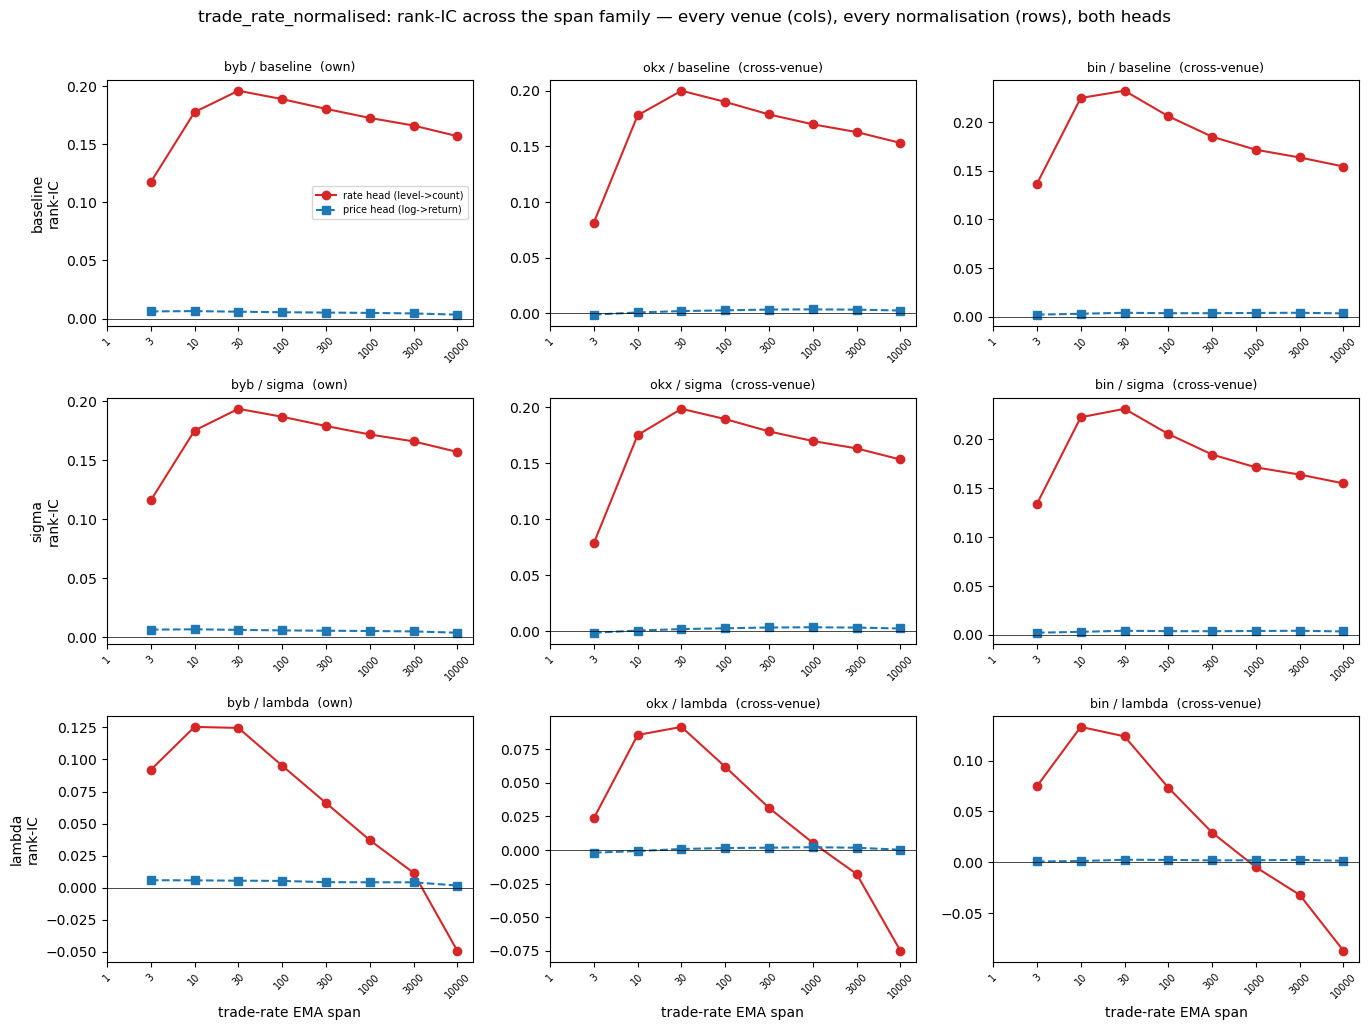

best span per venue at normalisation 'lambda' (in-sample pick; re-scored OOS below):
  byb:  rate head span=10 IC=+0.125   |  price head span=3 IC=+0.006
  okx:  rate head span=30 IC=+0.091   |  price head span=3 IC=-0.002
  bin:  rate head span=10 IC=+0.133   |  price head span=30 IC=+0.003


In [6]:
# Heat-maps: rate-head and price-head IC across the span family, per venue — for EACH normalisation (3 norms x 2 heads).
fig, axes = plt.subplots(len(NORMS), len(EXCHANGES), figsize=(4.6 * len(EXCHANGES), 3.4 * len(NORMS)), squeeze=False)
for r, nm in enumerate(NORMS):
    for c, ex in enumerate(EXCHANGES):
        ax = axes[r][c]
        ax.plot(range(len(SPANS)), ic_rate[(ex, nm)], "o-", color="C3", label="rate head (level->count)")
        ax.plot(range(len(SPANS)), ic_price[(ex, nm)], "s--", color="C0", label="price head (log->return)")
        ax.axhline(0, color="k", lw=0.5); ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, rotation=45, fontsize=7)
        ax.set_title(f"{ex} / {nm}" + ("  (own)" if ex == "byb" else "  (cross-venue)"), fontsize=9)
        if c == 0: ax.set_ylabel(f"{nm}\nrank-IC")
        if r == len(NORMS) - 1: ax.set_xlabel("trade-rate EMA span")
        if r == 0 and c == 0: ax.legend(fontsize=7)
fig.suptitle("trade_rate_normalised: rank-IC across the span family — every venue (cols), every normalisation (rows), both heads", y=1.005)
fig.tight_layout(); plt.show()

# In-sample pick of the best span PER head PER venue, at the winning normalisation (used only to choose; re-scored OOS by the gates).
def best_span(arr): return int(np.nanargmax(np.abs(arr)))
rate_member  = {ex: best_span(ic_rate[(ex, BEST_NORM)])  for ex in EXCHANGES}
price_member = {ex: best_span(ic_price[(ex, BEST_NORM)]) for ex in EXCHANGES}
print(f"best span per venue at normalisation '{BEST_NORM}' (in-sample pick; re-scored OOS below):")
for ex in EXCHANGES:
    print(f"  {ex}:  rate head span={SPANS[rate_member[ex]]} IC={ic_rate[(ex,BEST_NORM)][rate_member[ex]]:+.3f}"
          f"   |  price head span={SPANS[price_member[ex]]} IC={ic_price[(ex,BEST_NORM)][price_member[ex]]:+.3f}")

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_18981/3192182176.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic


  byb: best alt span=3000 IC|best +0.004;  OOS joint +0.004 vs solo -0.004 (Δ+0.008)  ->  one span suffices (no OOS gain)


/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_18981/3192182176.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic


  okx: best alt span=1000 IC|best +0.003;  OOS joint +0.003 vs solo -0.002 (Δ+0.005)  ->  one span suffices (no OOS gain)


...

  byb: best alt span=10000 IC|best -0.059;  OOS joint +0.117 vs solo +0.121 (Δ-0.004)  ->  one span suffices (no OOS gain)


/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_18981/3192182176.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic


  okx: best alt span=10000 IC|best -0.114;  OOS joint +0.115 vs solo +0.102 (Δ+0.013)  ->  KEEP 2nd span (adds OOS)


/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_18981/3192182176.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic


  bin: best alt span=10000 IC|best -0.148;  OOS joint +0.154 vs solo +0.144 (Δ+0.010)  ->  one span suffices (no OOS gain)


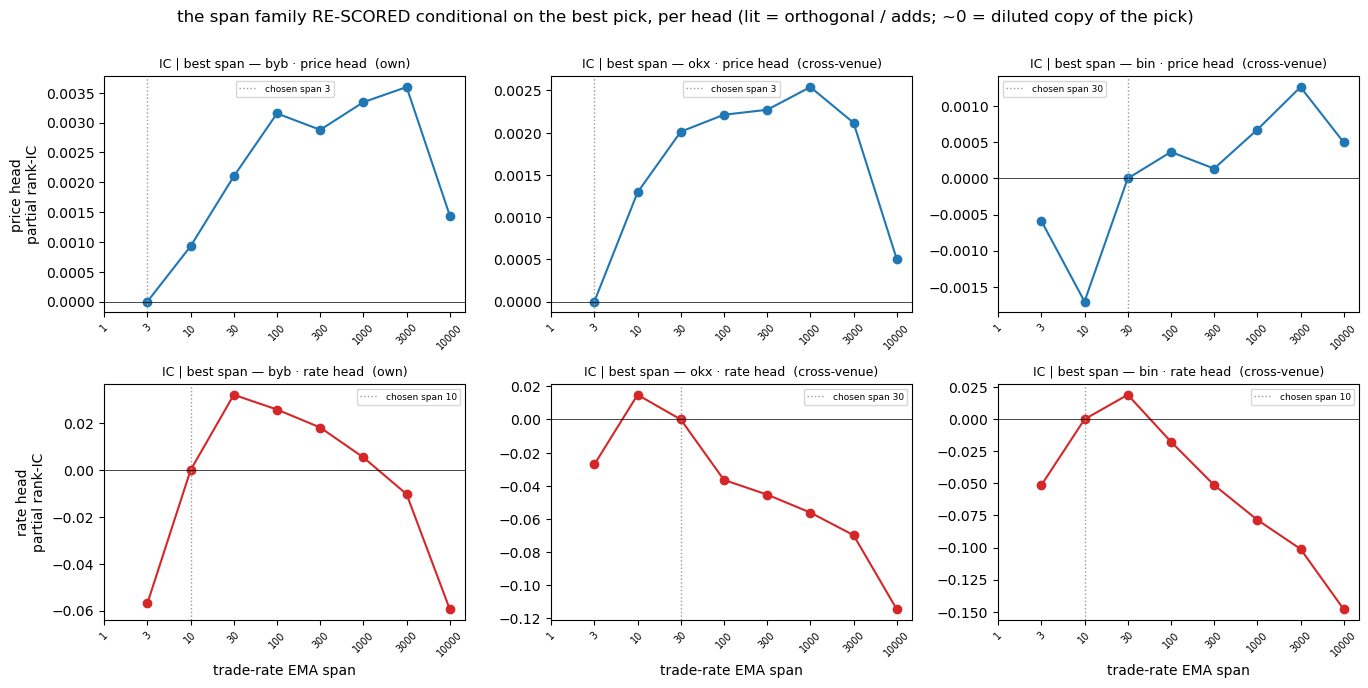

In [7]:
# === Does a SECOND time-scale ADD over the pick? — the sweep RE-SCORED conditional on the best span, PER HEAD ===
# Selection lives here in §6. We picked the best span per head by IC; now re-score the WHOLE span family as
# partial-IC(cell | chosen) -- each span's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span). This family is a SINGLE span N
# (1-D sweep), so the reconditioned sweep is 1-D too -- one partial-IC per span, drawn as a per-head line.
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. The line is
# in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a span to the head's scored input (rate head = the LEVEL; price head = the signed log),
# tgt is the head's target, member is the in-sample pick (a span index).
HEADS = [("price head", lambda ex, N: np.log(np.maximum(trade_rate_normalised(ex, N, BEST_NORM), 1e-12)), target,      price_member),
         ("rate head",  lambda ex, N: trade_rate_normalised(ex, N, BEST_NORM),                            rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(EXCHANGES), figsize=(4.6 * len(EXCHANGES), 3.4 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(EXCHANGES):
        ci = member[ex]; chosen = feat(ex, SPANS[ci])
        cond = np.full(len(SPANS), np.nan)
        for i, N in enumerate(SPANS):
            cond[i] = 0.0 if i == ci else _pic(feat(ex, N), tgt, chosen)
        ax = axes[row][col]
        ax.plot(range(len(SPANS)), cond, "o-", color="C3" if head == "rate head" else "C0")
        ax.axhline(0, color="k", lw=0.5); ax.axvline(ci, color="0.6", ls=":", lw=1.0, label=f"chosen span {SPANS[ci]}")
        ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, rotation=45, fontsize=7)
        ax.set_title(f"IC | best span — {ex} · {head}" + ("  (own)" if ex == "byb" else "  (cross-venue)"), fontsize=9)
        if col == 0: ax.set_ylabel(f"{head}\npartial rank-IC")
        if row == len(HEADS) - 1: ax.set_xlabel("trade-rate EMA span")
        ax.legend(fontsize=6.5)
        cand = np.array([abs(c) if i != ci else -np.inf for i, c in enumerate(cond)])  # exclude the chosen span itself
        bi = int(np.nanargmax(cand))                                                   # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, feat(ex, SPANS[bi])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                           # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                            # the OOS joint gain DECIDES
        second[(head, ex)] = bi if keep else None
        print(f"  {ex}: best alt span={SPANS[bi]} IC|best {cond[bi]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the span family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC sweep picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span family conditional
on the chosen pick** — each span's IC recomputed as `partial-IC(span | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell uses;
control = the chosen span). A span that stays **lit** is **orthogonal** — it adds new signal — while a span that
**collapses to ≈ 0** is a diluted copy of the pick. Because that line is **in-sample**, the keep/drop **decision**
is the overfitting-resistant **walk-forward joint-vs-solo** IC (`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the
second span only when the out-of-sample gain clears the ~0.01 floor. We run it for **both heads** (rate → the
trade-rate level vs the count target, its home; price → the signed log vs the σ-return target) and for **every
venue**, picking the most-orthogonal span as the candidate alternative. On this block almost every leg finds the
second span a diluted copy (OOS gain below the ~0.01 floor — one span suffices), the lone exception being the
**okx rate-head** leg, where adding the long (10000) span clears the floor (OOS Δ ≈ +0.013, KEEP) — a genuine
orthogonal slow-pace component on that one cross-venue leg.

**Now the gates** (from §5), on the per-venue rate-head picks at the winning normalisation. Every
predictive number is the **walk-forward** mean (causal, purged). They are **two independent tests**.

**Gate A — regime invariance** (the feature *alone*, run **per venue** — Gate A is a distribution property,
which differs by venue *and* by span): is the feature's distribution **stable against our regime
diagnostics**? **scale** — its std across vol buckets (max/min, want **< ~3**); and for **both the signed
feature and its magnitude `|feature|`** (the rate head receives the signed feature and can learn its
magnitude), against **both** the vol and rate coordinate: **tracking** — `|IC(·, level)|` (want **< ~0.05**
signed, **< ~0.1** magnitude) — and **dispersion** (per-decile-mean spread, want **< ~0.1**). The vol/rate
level is only the regime *coordinate* here, **never** a control.

**Gate B — predictive signal**: does it predict? `trade_rate_normalised` is `FEATURE_KIND="control"` (a
trade-rate regime descriptor), but — crucially — it is **NOT circular** with the move-rate control:
**trade ≠ move** (trade-no-move, move-no-trade), so even byb's own trade-rate leg's honest test is the
**marginal** rank-IC over the regime-invariant controls (the momenta — **never** the raw levels),
`own=False` for **every** leg. **Mechanical-coupling guard:** the shipped form divides by `λ_ev` and is
scored on the `count/λ_ev` rate target, so they share the λ_ev denominator (`STRAT_VAR = lam_at_anchor`);
we add a **within-λ_ev stratified** line per leg to confirm the marginal isn't a `1/λ_ev` arithmetic
artefact. We also report the marginal for **all three normalisations** so the §3 normalisation axis is
settled out-of-sample. *Regime-stable* (companion): is the gain still positive within calm/mid/wild vol?

In [8]:
# === RATE-HEAD GATES === (the feature's home), per venue, at the shipped normalisation. scored against the COUNT target.
# GATE B — predictive signal. trade_rate_normalised is a CONTROL (a trade-rate regime descriptor) BUT NOT circular with
# the move-rate control (trade≠move), so EVERY leg's honest test is the MARGINAL over the controls (own=False), not a
# standalone IC. signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). STRAT_VAR=lam_at_anchor (the shipped ÷λ_ev shares the count/λ_ev
# target's denominator) is consumed by the explicit within-λ_ev coupling rows below; the marginal branch is the usual
# nested-model incremental IC.
surge = {ex: feat_cache[(ex, SPANS[rate_member[ex]], BEST_NORM)] for ex in EXCHANGES}   # rate-head pick per venue (positive intensity)

# Marginal value on the RATE head, PER LEG (the honest per-exchange test) + JOINT (all venues together).
m_each    = {ex: signal_ic([surge[ex]], own=False, tgt=rate_target) for ex in EXCHANGES}
m_joint   = signal_ic(list(surge.values()), own=False, tgt=rate_target)
m_cross   = signal_ic([surge["okx"], surge["bin"]], own=False, tgt=rate_target)   # okx+bin cross-venue only (no byb)
jci       = wf_marginal_ci(list(surge.values()), rate_target)   # per-fold spread + block-bootstrap CI for the joint marginal
strat     = signal_ic_by_regime(list(surge.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
print(f"joint Gate B (rate) marginal {m_joint:.3f}  |  per-fold {jci['per_fold']} (positive in {jci['pos']}/{jci['nf']})  "
      f"|  block-bootstrap 90% CI [{jci['ci'][0]}, {jci['ci'][1]}]  (block ~{jci['block_len']} anchors ~{jci['block_s']}s)")

# NORMALISATION decided out-of-sample: joint marginal (all venues) over the controls, for each normalisation, best span per venue per norm.
def joint_marg_for(norm):
    legs = [feat_cache[(ex, SPANS[best_span(ic_rate[(ex, norm)])], norm)] for ex in EXCHANGES]
    return signal_ic(legs, own=False, tgt=rate_target)
norm_marg = {nm: joint_marg_for(nm) for nm in NORMS}

# normaliser scale gate (HARD): SHIPPED-variant scale across vol buckets, worst venue. Plus the BASELINE scale for contrast.
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def _scale(arr):
    bs = [np.nanstd(arr[vol_decile == d]) for d in range(10)]; bs = [b for b in bs if np.isfinite(b) and b > 0]
    return (max(bs) / min(bs)) if len(bs) >= 2 else float("inf")
ship_scale = round(max(_scale(surge[ex]) for ex in EXCHANGES), 2)
base_scale = round(max(_scale(feat_cache[(ex, SPANS[best_span(ic_rate[(ex, 'baseline')])], 'baseline')]) for ex in EXCHANGES), 2)

# LOW-1 sanity: a "control" SHOULD overlap the momenta (it IS a regime descriptor) — but trade≠move, so the overlap is MODERATE, not huge.
rep = surge["byb"]
print(f"FEATURE_KIND={FEATURE_KIND!r} | byb trade-rate vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (a control overlaps the regime; trade≠move keeps it moderate)")

gate_rows  = [dict(gate="B · signal (rate)", detail=f"{ex} leg alone — marginal over rate+vol MOMENTA"
                   + ("  [byb own trades]" if ex == "byb" else "  [cross-venue]"), value=m_each[ex]) for ex in EXCHANGES]
gate_rows += [
    dict(gate="B · signal (rate)", detail=f"all three venues JOINTLY over controls (norm='{BEST_NORM}'); want >~ 0.01", value=m_joint),
    dict(gate="B · signal (rate)", detail="okx+bin CROSS-VENUE legs only (no byb) over controls", value=m_cross),
]
gate_rows += [dict(gate="B · coupling (rate)", detail=f"{ex} — surge->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(surge[ex], rate_target, lam_at_anchor), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="normalisation (rate)", detail=f"joint marginal over controls, normalisation='{nm}'", value=norm_marg[nm]) for nm in NORMS]
gate_rows += [
    dict(gate="normaliser scale (HARD)", detail=f"SHIPPED '{BEST_NORM}' scale across vol buckets, worst venue (want < ~3)", value=ship_scale),
    dict(gate="normaliser scale (HARD)", detail="baseline scale, worst venue — the non-invariant level we REJECTED", value=base_scale),
]
for ex in EXCHANGES:                                       # GATE A PER VENUE (worst coordinate per check)
    a = gate_a(surge[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable (rate)", detail=f"joint marginal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

joint Gate B (rate) marginal 0.107  |  per-fold [0.09, 0.132, 0.097, 0.115, 0.098] (positive in 5/5)  |  block-bootstrap 90% CI [0.101, 0.114]  (block ~9479 anchors ~474.0s)


FEATURE_KIND='control' | byb trade-rate vs momenta |IC|: rate 0.220 vol 0.018  (a control overlaps the regime; trade≠move keeps it moderate)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""byb leg alone — marginal over rate+vol MOMENTA [byb own trades]""",0.057
"""B · signal (rate)""","""okx leg alone — marginal over rate+vol MOMENTA [cross-venue]""",0.043
"""B · signal (rate)""","""bin leg alone — marginal over rate+vol MOMENTA [cross-venue]""",0.089
"""B · signal (rate)""","""all three venues JOINTLY over controls (norm='lambda'); want >~ 0.01""",0.107
"""B · signal (rate)""","""okx+bin CROSS-VENUE legs only (no byb) over controls""",0.096
"""B · coupling (rate)""","""byb — surge->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artef…",0.125
"""B · coupling (rate)""","""okx — surge->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artef…",0.119
"""B · coupling (rate)""","""bin — surge->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artef…",0.166
"""normalisation (rate)""","""joint marginal over controls, normalisation='baseline'""",0.112


**Conclusion — read per leg and per normalisation.** On this block the trade-rate feature clears Gate B
handsomely on the rate head, and the trade≠move reckoning pays off. **Gate B (marginal over the controls):**
the joint marginal over all three venues is **+0.107** — positive in **5/5** OOS folds with a tight
block-bootstrap 90% CI **[0.101, 0.114]** — far above the ~0.01 floor and well above the controls-only rate
bar (0.071). Per leg, **bin +0.089**, **byb +0.057**, **okx +0.043** all clear on their own, and the
**cross-venue-only** legs (okx+bin, no byb) add **+0.096** — so this *is* genuinely new intensity
information the byb move-rate control lacked (trade-no-move / move-no-trade slack), and the cross-venue
legs are not riding on byb's own. Within **λ_ev strata** the signal stays robustly positive (byb 0.125, okx
0.119, bin 0.166), so the marginal is **not** a `1/λ_ev` arithmetic artefact. **The normalisation choice is
regime-invariance-FIRST, IC second:** raw `baseline` is the highest-IC variant (joint marginal 0.112, mean
best rate-IC 0.209) **but a non-invariant level** — its scale wanders **4.24×** across vol buckets, failing
the hard <3× gate — and **÷σ_ev also fails** (**3.07×**, joint marginal 0.116); only **÷λ_ev** (trades per
byb-mid-move) clears the gate at **2.32×**, at a real but acceptable IC cost (joint marginal 0.107). So the
**shipped form is `÷λ_ev`**, the only regime-invariant variant. **Gate A is run per venue**, and here it
shows the **control** nature honestly: scale is steady (byb 1.48, okx 1.73, bin 2.32 — all < 3), but the
feature **does track the regime level** — mean-track **0.014 (byb) / 0.169 (okx) / 0.265 (bin)** and
dispersion up to **0.16 (bin)**, above the ~0.05/~0.1 alpha bars. That is **not** a disqualifying "level in
disguise" leak — a regime descriptor is *allowed* to correlate with the rate coordinate by construction
(byb's trade-rate |IC| with `rate_momentum` is **0.220**, the control signature); the byb leg is the
*least* regime-tracking (its trade rate is the freshest-but-noisiest read), the cross-venue okx/bin legs
track more because they smooth toward the shared pace. The **companion** confirms the gain is **not** a
one-regime artefact — positive in every regime (**0.103 / 0.110 / 0.098** for calm / mid / wild). Quote the
§6 marginal of the *shipped invariant form (÷λ_ev)*, never a raw IC of the non-invariant baseline.

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

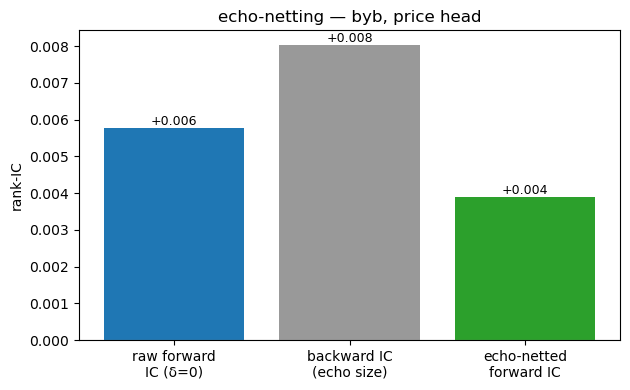

raw forward IC +0.006;  backward (echo) IC +0.008;  echo-netted forward IC +0.004  (the raw->netted shortfall is echo)


In [9]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = EXCHANGES[0]                                   # one exchange to illustrate; every feature carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = np.log(np.maximum(trade_rate_normalised(rep_ex, SPANS[price_member[rep_ex]], BEST_NORM), 1e-12))  # the chosen price-head feature (signed log)
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature and look at
the real distributions the heads care about, **per venue** (byb's own trade intensity vs the cross-venue
legs):
- **rate head (its home):** how the number of upcoming byb moves grows as each venue's trade rate grows;
- **price head (diagnostic):** byb's next return for low / middle / high *signed* (log) feature — expected
  roughly flat, since intensity isn't direction.

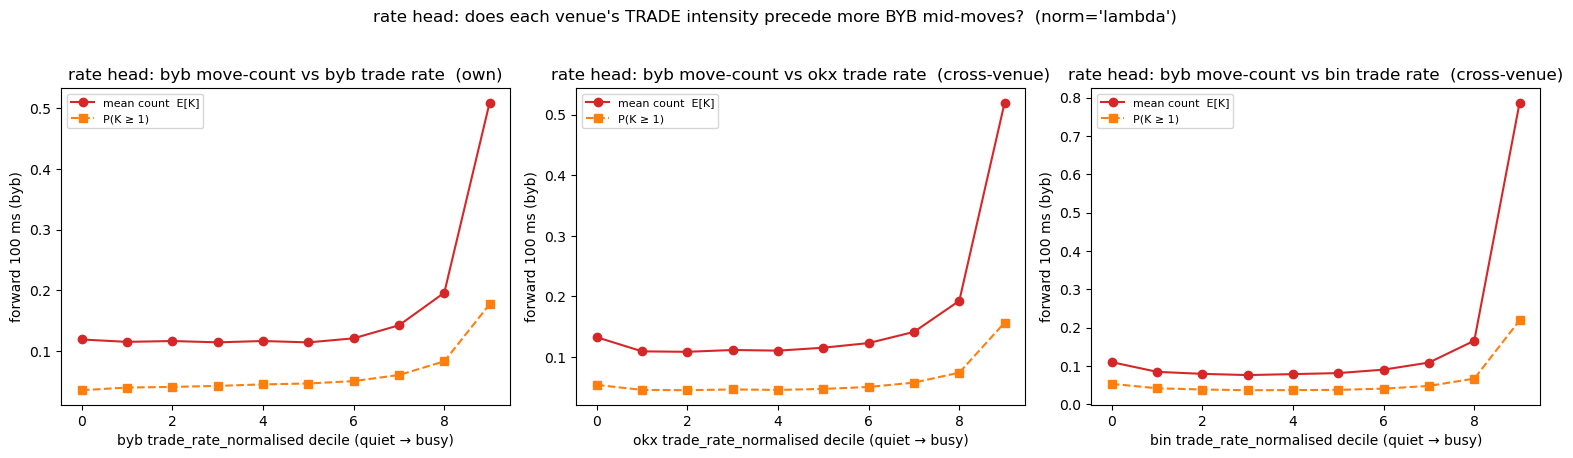

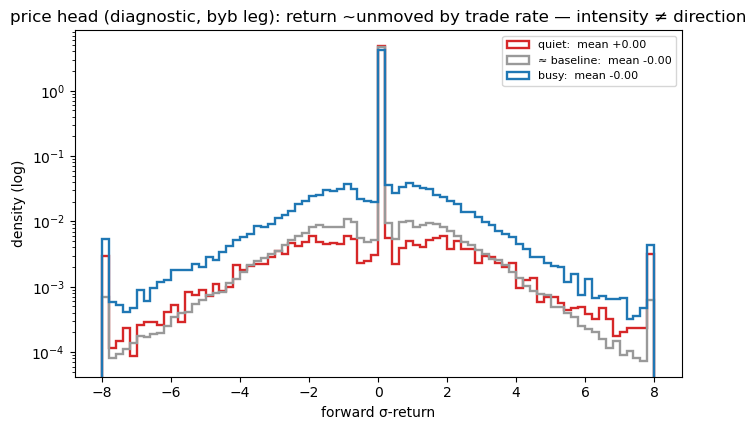

In [10]:
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    s = surge[ex]; ax = axes[0][col]
    dec = np.digitize(s, np.nanpercentile(s[np.isfinite(s)], np.arange(10, 100, 10)))
    ax.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
    ax.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
    ax.set_xlabel(f"{ex} trade_rate_normalised decile (quiet → busy)"); ax.set_ylabel("forward 100 ms (byb)")
    ax.set_title(f"rate head: byb move-count vs {ex} trade rate" + ("  (own)" if ex == "byb" else "  (cross-venue)")); ax.legend(fontsize=8)
fig.suptitle(f"rate head: does each venue's TRADE intensity precede more BYB mid-moves?  (norm='{BEST_NORM}')", y=1.03)
fig.tight_layout(); plt.show()

# price head (diagnostic): forward σ-return across signed log-feature buckets — expected ~flat — shown for the byb leg
s = surge["byb"]; ls = np.log(np.maximum(s, 1e-12))
fig, axB = plt.subplots(1, 1, figsize=(7, 4.4))
lo, hi = np.nanpercentile(ls, [10, 90])
groups = [("quiet", ls <= lo, "C3"), ("≈ baseline", (ls > lo) & (ls < hi), "0.6"), ("busy", ls >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic, byb leg): return ~unmoved by trade rate — intensity ≠ direction"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (top):** read the per-venue panels — for the **byb** leg the mean move-count
`E[K]` and `P(K ≥ 1)` climb from quiet to busy trade-rate deciles (the §1 intensity story); the **okx/bin**
panels show whether *another* venue's trade intensity also tracks byb's upcoming move-count (a cross-venue
lead) or is flat (no cross-venue content). **Price head (bottom):** the forward-return distribution barely
shifts across quiet / baseline / busy groups (means ≈ 0) — trade rate says *how many*, not *which way*,
confirming this is an intensity feature. The open question §6 answers is whether any leg's signal is **new
over the move-rate control** — which, because trade rate ≠ move rate, it can be.

## 8. Input shaping for the network

This reshapes the feature for the network's input — roughly centred, unit-scale, no wild outliers — a
*different* step from §3's normalisation (which strips the regime; this just conditions the number). A
trade *rate* (or a rate ÷ yardstick) is positive and right-skewed (a burst can be many× baseline; a lull
is floored at 0), so its **log** is the natural signed, centred form. We feed **every venue's** log feature
(none privileged). Plot the byb leg (left) and compare candidates by how close to a clean bell curve they
make it (right — points on the diagonal are perfectly normal). Pick the lightest transform that clears the
bar; the same transform applies per venue.

raw feature: skew=+32.94  excess_kurt=2471.3
log feature: skew=-4.13  excess_kurt=112.0  (0 = normal)
  raw rate (z)           excess_kurt=2471.3   max|·|=165.8
  log (z)                excess_kurt= 112.0   max|·|=53.8
  log robust + clip ±4   excess_kurt=   1.1   max|·|=4.0
  rank-Gaussian(log)     excess_kurt=  -0.0   max|·|=5.0


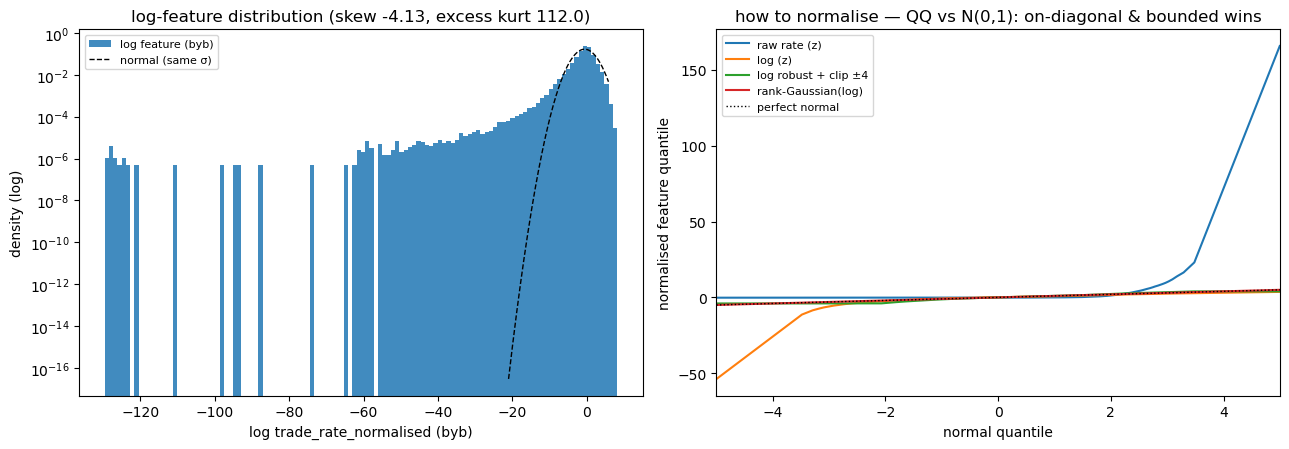

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = surge["byb"]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                       # log a positive rate: the natural centred, signed form
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)) + 1e-12; rz = (lf - med) / mad
cand = {"raw rate (z)": (f - f.mean()) / f.std(),
        "log (z)": (lf - lf.mean()) / lf.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian(log)": norm.ppf((rankdata(lf) - 0.5) / len(lf))}
print(f"raw feature: skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}")
print(f"log feature: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lf, bins=120, density=True, color="C0", alpha=.85, label="log feature (byb)")
xg = np.linspace(np.percentile(lf, 0.05), np.percentile(lf, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lf.mean(), lf.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log trade_rate_normalised (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"log-feature distribution (skew {skew(lf):+.2f}, excess kurt {kurtosis(lf):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(lf) + 1) - 0.5) / len(lf)); sub = np.linspace(0, len(lf) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The raw trade-rate feature is violently right-skewed and fat-tailed (skew **+32.9**, excess
kurtosis **2471**, max|·| ~166 after a plain z-score). Taking the **log** tames it dramatically (skew
**−4.13**, excess kurt **112**) but a plain z-score of the log still leaves a ~54σ spike — far past the
"no wild outliers" bar. The lightest transform that *clears* the bar is **log → robust-z → clip ±4**
(excess kurt 1.1, max|·| = 4.0). The heavier rank-Gaussian(log) flattens further (excess kurt ≈0) but
throws away the meaningful gradations. So: feed `log(trade_rate_normalised)` per venue, robust-standardised
and clipped ±4 — at the normalisation §6 chose (`÷λ_ev`).

**Still to run** (same machinery): whether the feature adds over features we already have; whether the
signal is steady day-to-day; and whether it survives out-of-sample across a market-regime change. (The leak
check *inside* volatility buckets is no longer pending — Gate A's checks and the regime-stable companion now
run it.)

## 9. When is per-exchange worth it? — short vs long lookback (for poolable features)

`trade_rate_normalised` is a **poolable** per-venue feature (one rate per venue), so the template's
per-exchange question *does* apply here: keep them **per-exchange**, collapse to a **single** venue, or
**pool** them? The answer depends on the time-scale — so we sweep the **span** (the lookback) and compare
the three, walk-forward, on the rate head, at the chosen normalisation. (This is a genuine computation, not
an illustrative note: a per-venue rate *can* be pooled, unlike the template's cross-venue gap.)

**The mechanism, and what to expect.** The cross-venue edge is a **trade-intensity lead/lag** — one venue
trading heavily a beat before another. At **short** spans the venues genuinely differ (who is busy first),
so the per-venue set carries distinct cross-venue lead/lag and should beat a single venue; at **long**
spans every venue's smoothed trade rate converges to the same slow pace, so a **single** venue already says
what the rest do. We compute, at each span: the **per-exchange** marginal (all three legs), the **single
best** venue's marginal, the **pooled** (mean log-rate) marginal, and the **cross-venue-only** (okx+bin)
marginal — each over the controls, walk-forward.

In [12]:
# Sweep the span (lookback). Compare per-exchange / single / pooled / cross-venue, at the chosen normalisation, on the rate head.
def _marg(legs):                                                         # joint marginal over the controls = the signal_ic marginal branch
    return signal_ic(legs, own=False, tgt=rate_target)
look_rows = []
for k, N in enumerate(SPANS):
    legs = {ex: feat_cache[(ex, N, BEST_NORM)] for ex in EXCHANGES}      # one rate per venue at this span
    per_ex  = _marg(list(legs.values()))                                 # all three legs
    singles = {ex: _marg([legs[ex]]) for ex in EXCHANGES}
    best_ex = max(singles, key=singles.get); single = singles[best_ex]
    logs    = [np.log(np.maximum(legs[ex], 1e-12)) for ex in EXCHANGES]
    pooled  = _marg([np.nanmean(np.column_stack(logs), axis=1)])         # pooled = mean log-rate across venues
    cross   = _marg([legs["okx"], legs["bin"]])                          # okx+bin only (no byb)
    look_rows.append(dict(span=N, per_exchange=per_ex, best_single=f"{single} ({best_ex})", pooled=pooled, cross_venue_only=cross))
look_df = pl.DataFrame(look_rows)
print(f"rate-head marginal over controls, by span (lookback); normalisation = '{BEST_NORM}'")
print("per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-rate | cross_venue_only = okx+bin (no byb)")
look_df

rate-head marginal over controls, by span (lookback); normalisation = 'lambda'
per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-rate | cross_venue_only = okx+bin (no byb)


span,per_exchange,best_single,pooled,cross_venue_only
i64,f64,str,f64,f64
1,0.0,"""0.0 (byb)""",0.0,0.0
3,0.119,"""0.066 (bin)""",0.032,0.095
10,0.109,"""0.089 (bin)""",0.091,0.1
30,0.078,"""0.074 (bin)""",0.071,0.074
100,0.033,"""0.032 (bin)""",0.03,0.03
300,-0.002,"""0.005 (byb)""",-0.003,-0.004
1000,-0.018,"""-0.009 (okx)""",-0.014,-0.018
3000,-0.01,"""-0.003 (byb)""",-0.006,-0.009
10000,-0.007,"""-0.002 (byb)""",-0.005,-0.006


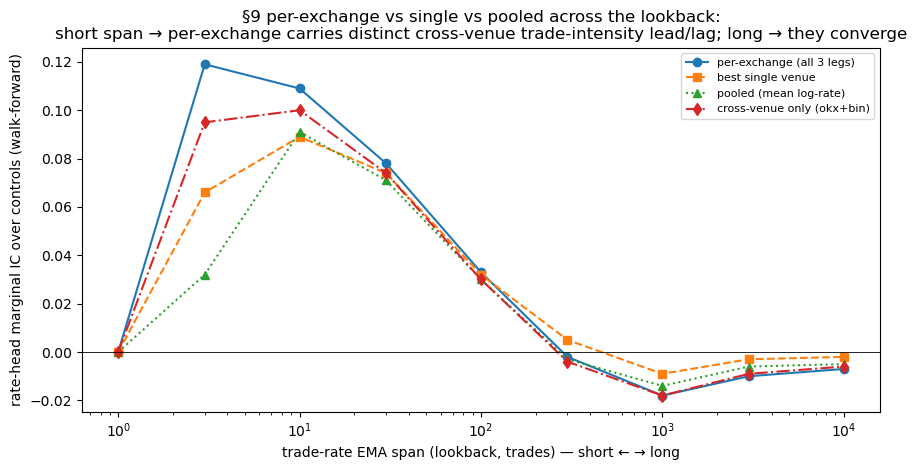

In [13]:
# Plot the per-exchange vs single vs pooled curves across the span sweep — the §9 cross-over picture.
xs = [r["span"] for r in look_rows]
per = [r["per_exchange"] for r in look_rows]
sin = [float(r["best_single"].split()[0]) for r in look_rows]
poo = [r["pooled"] for r in look_rows]
crs = [r["cross_venue_only"] for r in look_rows]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(xs, per, "o-", label="per-exchange (all 3 legs)", color="C0")
ax.plot(xs, sin, "s--", label="best single venue", color="C1")
ax.plot(xs, poo, "^:", label="pooled (mean log-rate)", color="C2")
ax.plot(xs, crs, "d-.", label="cross-venue only (okx+bin)", color="C3")
ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("trade-rate EMA span (lookback, trades) — short ← → long"); ax.set_ylabel("rate-head marginal IC over controls (walk-forward)")
ax.set_title("§9 per-exchange vs single vs pooled across the lookback:\nshort span → per-exchange carries distinct cross-venue trade-intensity lead/lag; long → they converge")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Conclusion — read the table and curves above.** The §9 picture on this block is the textbook cross-over.
At **short** spans the per-exchange set (all three legs) sits **above** the best single venue — span 3:
per-exchange **0.119** vs best single **0.066 (bin)**; span 10: **0.109** vs **0.089 (bin)** — so the
venues genuinely differ (who is trading heavily first is real cross-venue lead/lag), and keeping them
separate pays. As the span lengthens the curves **converge and then go to zero / slightly negative** (span
100: per-exchange 0.033 ≈ single 0.032; span ≥300: all ≈0 or negative) — every venue's slow trade rate has
settled to the same pace and the lookback stops carrying intensity. The **cross-venue-only** curve (okx+bin,
no byb) sits **above 0 at the short spans** (~0.095–0.10 at span 3–10), so another venue's trade intensity
genuinely leads byb's move-count over and above byb's own, and decays to ≈0 by long spans. (`span 1` reads
degenerate at 0.0.) So: **keep all three venues per-exchange at short lookbacks** (where the cross-venue
lead/lag lives); pooling tracks per-exchange but never beats it, and at long lookbacks the lookback itself
stops paying.

## 10. The verdict, and what it takes to ship

**`trade_rate_normalised(ex; N, y) = (W_trades(ex; N) / E_dt(N)) / y`** on the shared trade clock — a
single EMA of a venue's **trade** rate (trades/sec, one event per trade-timestamp), per venue, ÷ a regime
yardstick. **Keep it — feed the signed (log) feature to the rate head, all exchanges, at short lookbacks**
(byb=10, okx=30, bin=10 here). On this block it clears Gate B: joint marginal over the controls **+0.107**
(5/5 OOS folds, CI [0.101, 0.114]), every leg positive on its own (bin +0.089, byb +0.057, okx +0.043),
cross-venue-only +0.096; within-λ_ev strata it stays positive (0.12–0.17), and the companion holds across
calm/mid/wild (0.103 / 0.110 / 0.098). The price head is ≈0 — don't feed it expecting direction.

**The normalisation verdict (regime-invariance-FIRST).** The shipped normalisation is **not** the
highest-IC variant: the raw `baseline` trades/sec is the highest-IC variant in-sample (mean best rate-IC
0.209, joint marginal 0.112) **but a non-invariant level** — its scale wanders **4.24×** across vol
buckets, failing the hard <3× gate — and **÷σ_ev also fails** (**3.07×**). Only **÷λ_ev** (trades per
byb-mid-move) clears the gate, at **2.32×**, at a real but modest IC cost (joint marginal 0.107). So,
regime-invariance-FIRST, the **shipped form is `÷λ_ev`** — the most interpretable variant and the only
invariant one. The §6 `normaliser scale (HARD)` rows show it passing (2.32×) beside the rejected baseline
(4.24×).

**The control-circularity verdict — trade ≠ move.** `trade_rate_normalised` is `FEATURE_KIND="control"`
(a trade-rate regime descriptor), but it is **NOT circular** with the move-rate control: a trade need not
move the mid (trade-no-move) and the mid moves without trades (move-no-trade), so even byb's own trade rate
is not a re-parameterisation of `rate_momentum` (byb trade-rate |IC| with `rate_momentum` is 0.220 —
moderate, not the near-1 of a true clone). The honest test is therefore the **marginal over the rate/vol
controls** for **every** leg (§6), which is positive throughout. Gate A run per venue shows the control
nature honestly — scale steady (1.48–2.32 < 3) but the feature *does* track the regime level (mean-track
0.014 byb / 0.169 okx / 0.265 bin), which a regime descriptor is *allowed* to do; it is not a disqualifying
"level in disguise" leak.

**Echo-netted, not raw (the price-head diagnostic).** A raw forward IC over-credits the move already
underway at the anchor. The echo-netting section nets it out — the partial forward IC controlling for the
trailing `[anchor−100 ms, anchor]` return. For this **intensity** feature the price head is ≈0 either way
(direction isn't its job, so there is little echo to net), and the **rate-head** verdict rests on the §6
marginal over the controls, not a raw δ=0 IC. Report the **echo-netted** number, never a raw one, whenever a
forward IC is quoted for a head that carries signal.

**Cross-venue legs: a freshness lead is real edge.** The recording is production datacenter timing
(`rx_time` == live), so when okx (or bin) trades heavily a beat before byb's book reflects it, that lead is
**genuine and exploitable** — there is no recording/snapshot artifact to coarsen away. The §9 cross-venue-only
curve confirms the okx/bin legs add over byb's own at short spans (~0.10 at span 10) and converge to ≈0 by long
spans; keep them all, never collapse to one "leader."

Feed **every exchange's** signed log-feature in and let the model lean on whichever is leading; don't
collapse to one "leader."

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, per venue, matching this analysis version (§4, done)
- [ ] the §4 parity check and tests, passing **bit-exact for every per-venue leg × normalisation**
- [ ] **the SHIPPED normalisation** chosen regime-invariance-FIRST (only a norm that passes the <3× scale
      gate; read the §6 `normaliser scale (HARD)` rows for the call)
- [ ] the §6 marginal-over-controls recorded **per leg**, with the trade≠move call made
- [ ] the **echo-netted** forward IC recorded for any head that carries signal (don't quote a raw δ=0 IC)
- [ ] the §6 conditional-IC second-span test recorded per head (one span suffices unless it adds OOS)
- [ ] the §9 per-exchange-vs-single cross-over recorded (where per-exchange stops paying)
- [ ] the chosen rate-head span per venue written down, with the yardstick span
- [ ] the data quirks handled (bad zero-price prints; byb/okx mid = merged_levels, bin = front_levels;
      simultaneous prints = ONE trade-event; one decay per timestamp)